#########    All "our" in the following code refers to Joint Cabernet.

In [1]:
import pandas as pd
import numpy as np
from tqdm.notebook import tqdm
import anndata as ad
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from scipy.stats import gaussian_kde
import datetime

In [ ]:
# "indir" is a custom input path, and "outdir" is a custom output path.
indir = '../'
outdir = '../plots'

In [ ]:
from matplotlib.font_manager import fontManager, FontProperties
font_path = "/arial/arial.ttf"
fontManager.addfont(font_path)
font_prop = FontProperties(fname=font_path)
plt.rcParams['font.family'] = font_prop.get_name()

In [ ]:
subclass_list = pd.read_csv('../../../../03.data/04.config_files/subclass_order.csv', header=None)[0].to_list()
subclass_list=[i for i in subclass_list if "NN" not in i]

csv_path = "../../../../03.data/02.metainfo/01.Young_Mouse/subclass_name.Joint_Cabernet_corresponding_to_3C.csv"
df = pd.read_csv(csv_path, sep=',')
df = df.iloc[:len(subclass_list),:]

df_RNA=pd.read_csv('../../../03.Joint-Cabernet.cellType_State/04-Correlation_calculation/02-our_subclass_mean_dat_final.csv',index_col=0).T.loc[subclass_list,:]
max_threshold_=0.2
cv_threshold_=0.4
df_RNA_selected=df_RNA.loc[subclass_list,:]
df_RNA_selected=df_RNA_selected.loc[subclass_list,
    (df_RNA_selected.max(axis=0)>max_threshold_) &
    (df_RNA_selected.apply(lambda col: col.std() / col.mean(), axis=0)>cv_threshold_)
            ]

/tmp/ipykernel_23561/3321672375.py:14: RuntimeWarning: invalid value encountered in scalar divide
  (df_RNA_selected.apply(lambda col: col.std() / col.mean(), axis=0)>cv_threshold_)


In [ ]:
state="hyper"

df_frac_segment_subclass=dict()
df_frac_segment_subclass["5hmCG"]=ad.read_h5ad('5hmC_merged_allc_with_5hmC_segment.h5ad').to_df().iloc[:len(subclass_list),:]
df_frac_segment_subclass["5hmCG"].index=df_RNA.index

DMR_states_df=ad.read_h5ad('../../../04.subclass.DMR/03-stratified_RankSumTest_1vsOthers/01_subclasses_in_neuron_1vsOthers/5hmCG_DMR_states_neuron_1vsOthers.h5ad').to_df()

if state == "hyper":
    segment_differential_states=(DMR_states_df==1).sum(axis=0)
elif state == "hypo":
    segment_differential_states=(DMR_states_df==-1).sum(axis=0)
elif state == "all":
    segment_differential_states=(DMR_states_df.abs()==1).sum(axis=0)

differential_segments=segment_differential_states[segment_differential_states>0].index


In [7]:
# import standard python libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os

import cooltools
import cooler

import datetime

from matplotlib.colors import LogNorm

In [8]:
df_chrom30k_step10k = ad.read_h5ad(f'{indir}/5hmCG_frac_chrom30k_step10k_by_subclass/5hmCG_frac_chrom30k_step10k_by_subclass.h5ad').to_df().iloc[:len(subclass_list),]
df_chrom30k_step10k

chrom30k_step10k,chr1_0_30000,chr1_10000_40000,chr1_20000_50000,chr1_30000_60000,chr1_40000_70000,chr1_50000_80000,chr1_60000_90000,chr1_70000_100000,chr1_80000_110000,chr1_90000_120000,...,chr19_61340000_61370000,chr19_61350000_61380000,chr19_61360000_61390000,chr19_61370000_61400000,chr19_61380000_61410000,chr19_61390000_61420000,chr19_61400000_61430000,chr19_61410000_61431566,chr19_61420000_61431566,chr19_61430000_61431566
cell,,,,,,,,,,,,,,,,,,,,,
5hmC_L2_3_IT_CTX_Glut.Merge.allc,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5hmC_L4_5_IT_CTX_Glut.Merge.allc,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5hmC_L5_IT_CTX_Glut.Merge.allc,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5hmC_L6_IT_CTX_Glut.Merge.allc,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5hmC_IT_AON-TT-DP_Glut.Merge.allc,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5hmC_LA-BLA-BMA-PA_Glut.Merge.allc,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5hmC_L2_3_IT_RSP_Glut.Merge.allc,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5hmC_L4_RSP-ACA_Glut.Merge.allc,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5hmC_L5_ET_CTX_Glut.Merge.allc,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
#chrom_=genes_df[genes_df["gene_id"]==x].loc[:,"chromosome"].iloc[0]
print(f"initialization started at  {datetime.datetime.now()}")
resolution_=10_000

# indir = ''

mcool_file={subclass_liu : f'{indir}/{subclass_liu}.Q.10K.mcool'
           for subclass_liu in df['subclass_liu']}
clr={subclass_liu : cooler.Cooler(f'{mcool_file[subclass_liu]}::resolutions/{resolution_}') for subclass_liu in df['subclass_liu']}

matrixes_=dict()
for chrom_ in tqdm(['chr'+str(i) for i in [2,]]):
    matrixes_[chrom_]=[
               clr[subclass_liu].matrix(balance=True).fetch(chrom_)[:] 
                     for subclass_liu in df['subclass_liu']
           ] 
           
print(f"initialization finished at {datetime.datetime.now()}")

initialization started at  2025-11-20 17:27:04.451690


  0%|          | 0/1 [00:00<?, ?it/s]

initialization finished at 2025-11-20 17:29:59.276493


In [11]:
from scipy.stats import linregress

In [ ]:
colors_ = pd.read_csv('../../../03.data/04.config_files/subclass_color.csv', header=None, index_col=0)
colors_ = dict(colors_.loc[:, 1])

In [25]:
df['merged_allc']=df['subclass_our'].apply(lambda x : '5hmC_'+x.replace('/','_').replace(' ','_')+'.Merge.allc')
id_dict=dict()
for _, row_ in df.iterrows():
    id_dict[row_['merged_allc']]=row_['subclass_our']

In [ ]:
indir = '../'

df_60kb=ad.read_h5ad(f'{indir}/plotting_for_supplementary/example_Etl4/5hmCG_frac_60kb_bin_merged_allc.h5ad').to_df()
df_60kb.index=pd.Series(df_60kb.index).apply(lambda x : x if 'NN' in x else id_dict[x])
df_60kb=df_60kb.loc[subclass_list,:]
df_60kb

segment,chr2_19690000_19750000,chr2_19900000_20820000
cell,,
L2/3 IT CTX Glut,0.240439,0.284584
L4/5 IT CTX Glut,0.241926,0.297521
L5 IT CTX Glut,0.288471,0.350715
L6 IT CTX Glut,0.282915,0.348980
IT AON-TT-DP Glut,0.257529,0.277960
LA-BLA-BMA-PA Glut,0.285583,0.291747
L2/3 IT RSP Glut,0.278649,0.321599
L4 RSP-ACA Glut,0.326754,0.365574
L5 ET CTX Glut,0.290799,0.314024


In [28]:
gene_id_='ENSMUSG00000036617.16'

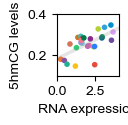

In [31]:
a=df_60kb[['chr2_19690000_19750000']]
b=df_RNA_selected[[gene_id_]]
a.index=b.index
a.columns=['5hmCG']
b.columns=['RNA']
c=pd.concat([a,b], axis=1)
plt.figure(figsize=(36/25.4,36/25.4))
slope, intercept, r_value, p_value, std_err = linregress(c['RNA'],c['5hmCG'])
#line_x=np.array([np.min(c['RNA']), np.max(c['RNA'])])
line_x=np.array([0,4])
plt.plot(line_x, slope*line_x + intercept, color='grey',alpha=0.2, linewidth=2.5)

plt.scatter(x=c['RNA'],y=c['5hmCG'],c=pd.Series(c.index).apply(lambda x : colors_[x]).to_list(), s=9)

plt.xlim((0,4));plt.ylim((0.1,0.4));
plt.xlabel('RNA expression');plt.ylabel('5hmCG levels')
ax = plt.gca()  # 获取当前轴对象
ax.set_aspect((4-0)/(0.4-0.1))
plt.tight_layout()
plt.savefig(f'{outdir}/03-scatter_RNA_5hmCG_PCC.pdf')
plt.savefig(f'{outdir}/03-scatter_RNA_5hmCG_PCC.png', dpi=600)

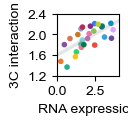

In [32]:
e=pd.DataFrame([np.nansum(matrixes_[chrom_][subclass_index]\
                       [1969: 1975, 1990:2082]) for subclass_index in range(len(subclass_list))])
b=df_RNA_selected[[gene_id_]]
e.index=b.index
e.columns=['3C interaction']
b.columns=['RNA expression']
f=pd.concat([e,b], axis=1)
plt.figure(figsize=(36/25.4,36/25.4))
slope, intercept, r_value, p_value, std_err = linregress(f['RNA expression'],f['3C interaction'])
#line_x=np.array([np.min(c['RNA']), np.max(c['RNA'])])
line_x=np.array([0,4])
plt.plot(line_x, slope*line_x + intercept, color='grey',alpha=0.2, linewidth=2.5)

plt.scatter(x=f['RNA expression'],y=f['3C interaction'],c=pd.Series(f.index).apply(lambda x : colors_[x]).to_list(), s=9)

plt.xlim((0,4));plt.ylim((1.2,2.4));plt.yticks([1.2,1.6,2.0,2.4])
plt.xlabel('RNA expression');plt.ylabel('3C interaction')
ax = plt.gca()  # 获取当前轴对象
ax.set_aspect((4-0)/(2.4-1.2))
plt.tight_layout()
plt.savefig(f'{outdir}/03-scatter_RNA_3C_PCC.pdf')
plt.savefig(f'{outdir}/03-scatter_RNA_3C_PCC.png', dpi=600)